**VISUALIZATION**

In [3]:
import pandas as pd
from matplotlib import pyplot as pt

In [4]:
df1 = pd.read_csv('daily-total-female-births-CA.csv',header=0, parse_dates=[0])
df1.head()

,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


<Axes: >

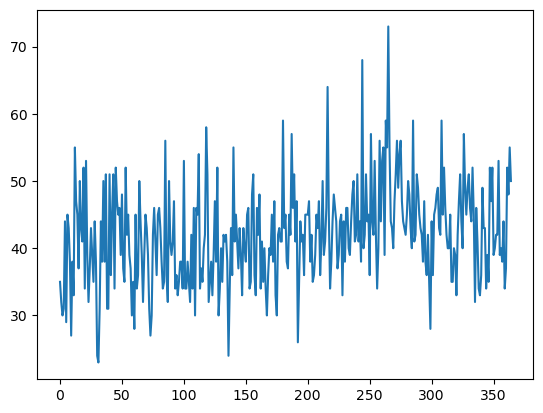

In [5]:
df1['births'].plot()

in this plot we have number of births in Y-axis and the index 0,1,2.. in X-axis

<Axes: xlabel='date'>

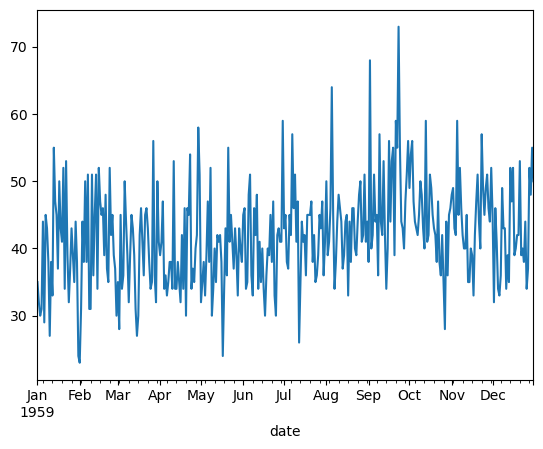

In [9]:
df1.index=df1['date']
df1['births'].plot()

*ZOOMING THE GRAPH*

- Here we create another data frame containing the required period then simply plot it

In [12]:
df2 = df1[(df1['date']>'1959-01-01') & (df1['date'] <= '1959-01-10')].copy()
df2

,date,births
date,,
1959-01-02,1959-01-02,32
1959-01-03,1959-01-03,30
1959-01-04,1959-01-04,31
1959-01-05,1959-01-05,44
1959-01-06,1959-01-06,29
1959-01-07,1959-01-07,45
1959-01-08,1959-01-08,43
1959-01-09,1959-01-09,38
1959-01-10,1959-01-10,27


<Axes: xlabel='date'>

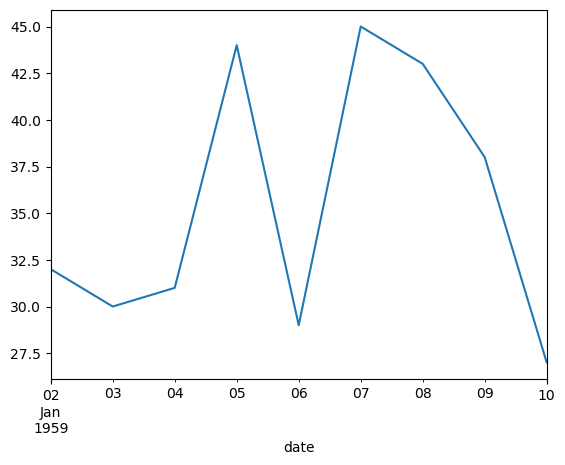

In [13]:
df2['births'].plot()

*TREND*

In [15]:
birth_df = pd.read_csv('daily-total-female-births-CA.csv', header=0, parse_dates=[0])
birth_df.head()

,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


- we use seaborn
- for scatter plot we need numerical values in axes

<Axes: ylabel='births'>

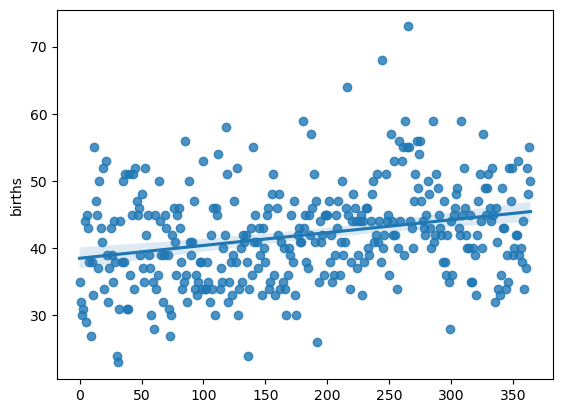

In [17]:
import seaborn as sns
sns.regplot(x=birth_df.index.values , y=birth_df['births'])

<Axes: ylabel='births'>

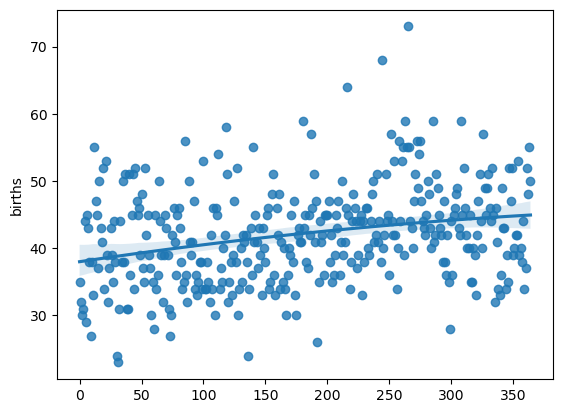

In [18]:
sns.regplot(x=birth_df.index.values , y=birth_df['births'], order = 2)

In [19]:
air_df = pd.read_csv('us-airlines-monthly-aircraft-miles-flown.csv', header = 0, parse_dates=[0])
air_df.head()

,Month,MilesMM
0,1963-01-01,6827
1,1963-02-01,6178
2,1963-03-01,7084
3,1963-04-01,8162
4,1963-05-01,8462


<Axes: >

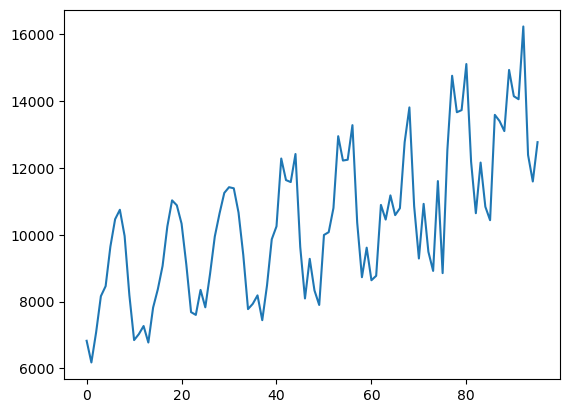

In [20]:
air_df['MilesMM'].plot()

<Axes: ylabel='MilesMM'>

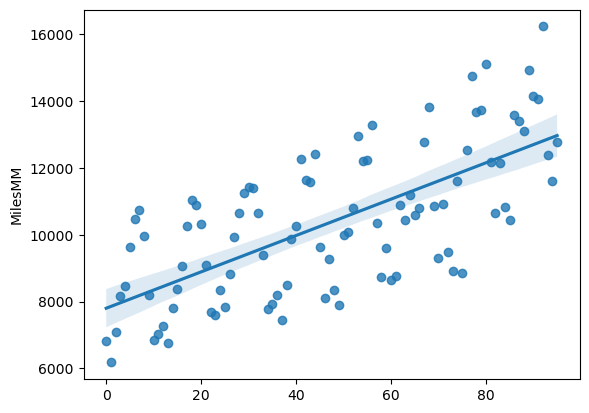

In [21]:
sns.regplot(x=air_df.index.values , y=air_df['MilesMM'])

*DE SEASONALIZIG*
- Groupby by year

In [22]:
air_df['year']=air_df['Month'].dt.year
air_df.head()

,Month,MilesMM,year
0,1963-01-01,6827,1963
1,1963-02-01,6178,1963
2,1963-03-01,7084,1963
3,1963-04-01,8162,1963
4,1963-05-01,8462,1963


In [24]:
air_df.groupby('year')['MilesMM'].mean()


year
1963     8300.250000
1964     8849.333333
1965     9619.250000
1966     9929.500000
1967    10542.916667
1968    10747.916667
1969    11972.000000
1970    13124.750000
Name: MilesMM, dtype: float64

<Axes: xlabel='year'>

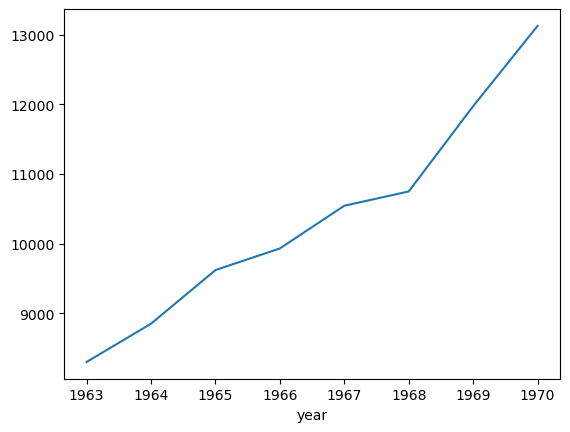

In [23]:
air_df.groupby('year')['MilesMM'].mean().plot()

*LAG PLOT*

In [25]:
air_df['lag 1']=air_df['MilesMM'].shift(1)
air_df.head()

,Month,MilesMM,year,lag 1
0,1963-01-01,6827,1963,NaN
1,1963-02-01,6178,1963,6827.0
2,1963-03-01,7084,1963,6178.0
3,1963-04-01,8162,1963,7084.0
4,1963-05-01,8462,1963,8162.0


<Axes: xlabel='lag 1', ylabel='MilesMM'>

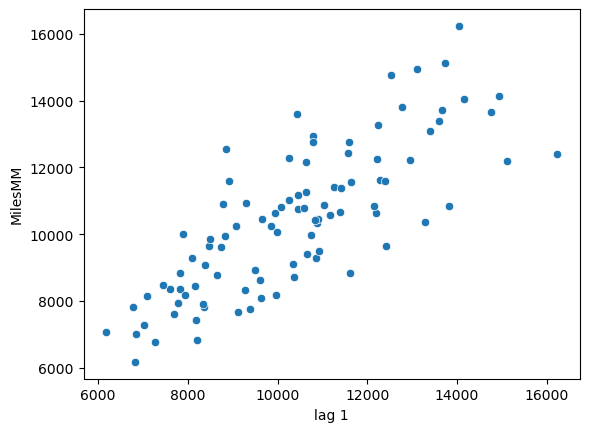

In [26]:
sns.scatterplot(x=air_df['lag 1'], y =air_df['MilesMM'])

same can be done using
  'from pandas.plotting import lag_plot'
  lag_plot(air_df['MilesMM'])

*AUTOCORRELATION*

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

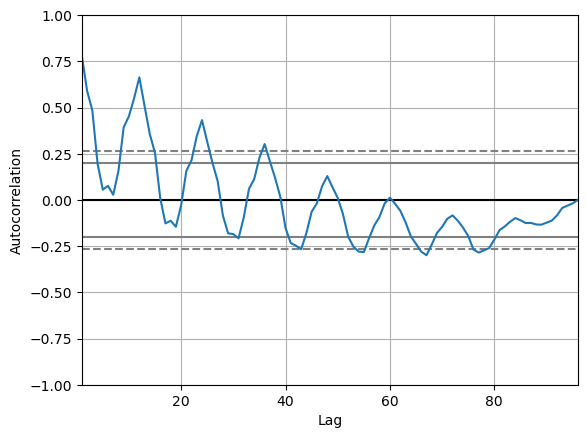

In [27]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(air_df['MilesMM'])